# CarPlate Colab Pipeline

The project focus on self custom made mode based YOLOv8 and the orginal YOLOv8 comparsion. We will use IoU and CIoU to evaluate the perfomance.
Assumption: dataset files are already downloaded or connected.

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
!pip install -q ultralytics torch torchvision pillow pyyaml numpy matplotlib

import csv
import os
from pathlib import Path
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
import yaml
from ultralytics import YOLO

SUPPORTED_IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
RESAMPLE_BILINEAR = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR


In [46]:
import xml.etree.ElementTree as ET
import yaml
from PIL import Image
import os
import shutil
import random
from pathlib import Path

def convert_voc_to_yolo(xml_file, output_txt_path, img_width, img_height):
    """Converts Pascal VOC XML to YOLO txt format with coordinate normalization."""
    tree = ET.parse(xml_file)
    root = tree.getroot()

    with open(output_txt_path, 'w') as f:
        for obj in root.iter('object'):
            cls_id = 0
            xmlbox = obj.find('bndbox')
            xmin = float(xmlbox.find('xmin').text)
            ymin = float(xmlbox.find('ymin').text)
            xmax = float(xmlbox.find('xmax').text)
            ymax = float(xmlbox.find('ymax').text)

            x_center = (xmin + xmax) / 2.0 / img_width
            y_center = (ymin + ymax) / 2.0 / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

def prepare_kaggle_data(image_dir, xml_dir, output_dir):
    print(f"Preparing data from: {image_dir} (images), {xml_dir} (annotations)")

    # Ensure standard YOLO directory structure
    for split in ['train', 'val']:
        os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, split, 'labels'), exist_ok=True)

    all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_xml_basenames = {os.path.splitext(f)[0] for f in os.listdir(xml_dir) if f.lower().endswith('.xml')}
    random.shuffle(all_images)

    split_idx = int(len(all_images) * 0.8)
    train_files = all_images[:split_idx]
    val_files = all_images[split_idx:]

    processed_xml_basenames = set()

    def process_set(files, split_name):
        print(f"Processing {len(files)} {split_name} images...")
        for img_name in files:
            img_basename = os.path.splitext(img_name)[0]
            xml_path = os.path.join(xml_dir, img_basename + ".xml")
            txt_path = os.path.join(output_dir, split_name, 'labels', img_basename + ".txt")
            shutil.copy(os.path.join(image_dir, img_name), os.path.join(output_dir, split_name, 'images', img_name))

            if os.path.exists(xml_path):
                processed_xml_basenames.add(img_basename)
                with Image.open(os.path.join(image_dir, img_name)) as img:
                    w, h = img.size
                convert_voc_to_yolo(xml_path, txt_path, w, h)
            else:
                with open(txt_path, 'w') as f: pass

    process_set(train_files, 'train')
    process_set(val_files, 'val')

    # Create data.yaml for YOLOv8
    yaml_content = {
        'path': os.path.abspath(output_dir),
        'train': 'train/images',
        'val': 'val/images',
        'names': {0: 'license_plate'}
    }

    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

    print(f"\nYAML config created at {output_dir}/data.yaml")

In [47]:
def autopad(k, p=None, d=1):
    if d > 1:
        k = d * (k - 1) + 1 if isinstance(k, int) else [d * (x - 1) + 1 for x in k]
    if p is None:
        p = k // 2 if isinstance(k, int) else [x // 2 for x in k]
    return p


class Conv(nn.Module):
    """Conv + BN + SiLU."""

    def __init__(self, c1, c2, k=1, s=1, p=None, g=1, d=1):
        super().__init__()
        self.conv = nn.Conv2d(c1, c2, k, s, autopad(k, p, d), groups=g, dilation=d, bias=False)
        self.bn = nn.BatchNorm2d(c2)
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class Bottleneck(nn.Module):
    def __init__(self, c1, c2, shortcut=True, g=1, k=(3, 3), e=0.5):
        super().__init__()
        c_ = int(c2 * e)
        self.cv1 = Conv(c1, c_, k[0], 1)
        self.cv2 = Conv(c_, c2, k[1], 1, g=g)
        self.add = shortcut and c1 == c2

    def forward(self, x):
        y = self.cv2(self.cv1(x))
        return x + y if self.add else y


class C2f(nn.Module):
    """YOLOv8-style C2f block."""

    def __init__(self, c1, c2, n=1, shortcut=False, g=1, e=0.5, bottleneck_expansion=1.0):
        super().__init__()
        self.c = int(c2 * e)
        self.cv1 = Conv(c1, 2 * self.c, 1, 1)
        self.cv2 = Conv((2 + n) * self.c, c2, 1, 1)
        # Bottlenecks maintain channel count by default (bottleneck_expansion=1.0).
        self.m = nn.ModuleList(
            Bottleneck(self.c, self.c, shortcut=shortcut, g=g, k=(3, 3), e=bottleneck_expansion) for _ in range(n)
        )

    def forward(self, x):
        y = list(self.cv1(x).chunk(2, 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, 1))


class SPPF(nn.Module):
    """Spatial Pyramid Pooling - Fast."""

    def __init__(self, c1, c2, k=5):
        super().__init__()
        c_ = c1 // 2
        self.cv1 = Conv(c1, c_, 1, 1)
        self.cv2 = Conv(c_ * 4, c2, 1, 1)
        self.m = nn.MaxPool2d(kernel_size=k, stride=1, padding=k // 2)

    def forward(self, x):
        x = self.cv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        y3 = self.m(y2)
        return self.cv2(torch.cat((x, y1, y2, y3), 1))


class DecoupledHead(nn.Module):
    """Decoupled cls/box prediction head for a single scale."""

    def __init__(self, in_channels, num_classes=1):
        super().__init__()
        self.cls_conv = Conv(in_channels, in_channels, 3, 1)
        self.cls_pred = nn.Conv2d(in_channels, num_classes, 1)

        self.box_conv = Conv(in_channels, in_channels, 3, 1)
        self.box_pred = nn.Conv2d(in_channels, 4, 1)

    def forward(self, x):
        cls_out = self.cls_pred(self.cls_conv(x))
        box_out = self.box_pred(self.box_conv(x))
        return cls_out, box_out


class ImprovedCustomYOLO(nn.Module):
    """Custom YOLO architecture with C2f backbone, SPPF, top-down FPN and multi-scale decoupled heads."""

    def __init__(self, num_classes=1):
        super().__init__()

        # Backbone
        self.stem = Conv(3, 16, 3, 2)  # P1/2
        self.layer1 = nn.Sequential(Conv(16, 32, 3, 2), C2f(32, 32, n=1, shortcut=True))  # P2/4
        self.layer2 = nn.Sequential(Conv(32, 64, 3, 2), C2f(64, 64, n=2, shortcut=True))  # P3/8
        self.layer3 = nn.Sequential(Conv(64, 128, 3, 2), C2f(128, 128, n=2, shortcut=True))  # P4/16
        self.layer4 = nn.Sequential(Conv(128, 256, 3, 2), C2f(256, 256, n=1, shortcut=True))  # P5/32
        self.sppf = SPPF(256, 256, k=5)

        # Neck (top-down FPN)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.neck_c2f_1 = C2f(256 + 128, 128, n=1, shortcut=False)  # P5 + P4
        self.neck_c2f_2 = C2f(128 + 64, 64, n=1, shortcut=False)  # fused P4 + P3

        # Multi-scale decoupled heads
        self.head_small = DecoupledHead(64, num_classes)  # stride 8
        self.head_medium = DecoupledHead(128, num_classes)  # stride 16
        self.head_large = DecoupledHead(256, num_classes)  # stride 32

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)

        p3 = self.layer2(x)
        p4 = self.layer3(p3)
        p5 = self.sppf(self.layer4(p4))

        p4_fused = self.neck_c2f_1(torch.cat([self.upsample(p5), p4], dim=1))
        p3_fused = self.neck_c2f_2(torch.cat([self.upsample(p4_fused), p3], dim=1))

        out_small = self.head_small(p3_fused)
        out_medium = self.head_medium(p4_fused)
        out_large = self.head_large(p5)

        return out_small, out_medium, out_large


In [48]:
def train_official_yolo(data_yaml="dataset/data.yaml", weights="yolov8n.pt", epochs=50, imgsz=640, batch=16):
    model = YOLO(weights)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        project="runs/official_yolo",
        name="car_plate_model",
    )
    print("Training complete. Best weights: runs/official_yolo/car_plate_model/weights/best.pt")

class LarxelDataset(Dataset):
    """Larxel-format dataset reader (updated to match <split>/images structure)."""

    def __init__(self, dataset_dir="dataset", split="train", img_size=640):
        self.dataset_dir = Path(dataset_dir)
        self.img_size = img_size
        # Match the structure created in prepare_kaggle_data: <split>/images and <split>/labels
        self.image_dir = self.dataset_dir / split / "images"
        self.label_dir = self.dataset_dir / split / "labels"

        if not self.image_dir.exists():
            raise FileNotFoundError(f"Image directory not found: {self.image_dir}")
        if not self.label_dir.exists():
            raise FileNotFoundError(f"Label directory not found: {self.label_dir}")

        self.image_files = sorted([p for p in self.image_dir.iterdir() if p.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS])
        if not self.image_files:
            raise ValueError(f"No images found in {self.image_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_path = self.image_files[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        image = Image.open(image_path).convert("RGB").resize((self.img_size, self.img_size), RESAMPLE_BILINEAR)
        image_tensor = TF.to_tensor(image)

        labels = []
        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id, x, y, w, h = map(float, parts[:5])
                    labels.append([cls_id, x, y, w, h])

        label_tensor = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0, 5), dtype=torch.float32)
        return image_tensor, label_tensor

# Keeps labels as a list so each image can carry a variable number of bounding boxes.
def collate_fn(batch):
    images = torch.stack([sample[0] for sample in batch], dim=0)
    labels = [sample[1] for sample in batch]
    return images, labels

def build_targets_for_scale(batch_labels, pred_cls, device):
    batch_size, _, grid_h, grid_w = pred_cls.shape
    target_cls = torch.zeros((batch_size, 1, grid_h, grid_w), device=device)
    target_box = torch.zeros((batch_size, 4, grid_h, grid_w), device=device)
    target_count = torch.zeros((batch_size, 1, grid_h, grid_w), device=device)

    for b_idx, labels in enumerate(batch_labels):
        if labels.numel() == 0:
            continue
        labels = labels.to(device)

        for label in labels:
            x, y, w, h = label[1], label[2], label[3], label[4]
            gx = min(max(int(x.item() * grid_w), 0), grid_w - 1)
            gy = min(max(int(y.item() * grid_h), 0), grid_h - 1)

            target_cls[b_idx, 0, gy, gx] = 1.0
            target_box[b_idx, 0, gy, gx] += x * grid_w - gx
            target_box[b_idx, 1, gy, gx] += y * grid_h - gy
            target_box[b_idx, 2, gy, gx] += w
            target_box[b_idx, 3, gy, gx] += h
            target_count[b_idx, 0, gy, gx] += 1.0

    target_box = target_box / target_count.clamp(min=1.0)
    return target_cls, target_box

def train_custom_model(
    epochs=50,
    batch_size=8,
    lr=1e-3,
    save_path="runs/custom_yolo/custom_yolo_best.pth",
    dataset_dir="dataset",
    img_size=640,
    num_workers=2,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ImprovedCustomYOLO(num_classes=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    cls_loss_fn = nn.BCEWithLogitsLoss()
    box_loss_fn = nn.MSELoss()

    save_dir = os.path.dirname(save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    train_dataset = LarxelDataset(dataset_dir=dataset_dir, split="train", img_size=img_size)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=device.type == "cuda",
        collate_fn=collate_fn,
    )

    best_loss = float("inf")
    model.train()
    print(f"Training custom model on {device}")
    print(f"Loaded {len(train_dataset)} training images from {train_dataset.image_dir}")

    for epoch in range(epochs):
        epoch_loss = 0.0
        processed_batches = 0

        for images, batch_labels in train_loader:
            images = images.to(device, non_blocking=True)

            optimizer.zero_grad()
            (cls_s, box_s), (cls_m, box_m), (cls_l, box_l) = model(images)

            target_cls_s, target_box_s = build_targets_for_scale(batch_labels, cls_s, device)
            target_cls_m, target_box_m = build_targets_for_scale(batch_labels, cls_m, device)
            target_cls_l, target_box_l = build_targets_for_scale(batch_labels, cls_l, device)

            loss = (
                cls_loss_fn(cls_s, target_cls_s)
                + box_loss_fn(box_s, target_box_s)
                + cls_loss_fn(cls_m, target_cls_m)
                + box_loss_fn(box_m, target_box_m)
                + cls_loss_fn(cls_l, target_cls_l)
                + box_loss_fn(box_l, target_box_l)
            )
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            processed_batches += 1

        if processed_batches == 0:
            raise RuntimeError("No training batches were processed. Check dataset and DataLoader settings.")

        avg_loss = epoch_loss / processed_batches
        print(f"Epoch [{epoch + 1}/{epochs}] loss={avg_loss:.4f} (batches={processed_batches})")

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path)
            print(f"Saved best custom checkpoint to {save_path}")

In [59]:
import pandas as pd
import numpy as np
import torch
import os
import time
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

def get_model_size_mb(model_path):
    return os.path.getsize(model_path) / (1024 * 1024)

def benchmark_official(model, runs=50, img_size=640):
    image = np.random.randint(0, 255, (img_size, img_size, 3), dtype=np.uint8)
    start = time.perf_counter()
    for _ in range(runs):
        model.predict(source=image, verbose=False)
    avg_seconds = (time.perf_counter() - start) / runs
    return avg_seconds

def benchmark_custom(model, device, runs=50, img_size=640):
    x = torch.randn(1, 3, img_size, img_size, device=device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(runs):
            model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    avg_seconds = (time.perf_counter() - start) / runs
    return avg_seconds

def yolo_to_xyxy(x, y, w, h, img_size):
    x1 = (x - w / 2.0) * img_size
    y1 = (y - h / 2.0) * img_size
    x2 = (x + w / 2.0) * img_size
    y2 = (y + h / 2.0) * img_size
    return [x1, y1, x2, y2]

def box_iou(box1, box2):
    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

def box_ciou(box1, box2):
    iou = box_iou(box1, box2)
    cx1, cy1 = (box1[0] + box1[2]) / 2.0, (box1[1] + box1[3]) / 2.0
    cx2, cy2 = (box2[0] + box2[2]) / 2.0, (box2[1] + box2[3]) / 2.0
    rho2 = (cx1 - cx2) ** 2 + (cy1 - cy2) ** 2
    enc_x1, enc_y1 = min(box1[0], box2[0]), min(box1[1], box2[1])
    enc_x2, enc_y2 = max(box1[2], box2[2]), max(box1[3], box2[3])
    c2 = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + 1e-7
    w1, h1 = max(box1[2] - box1[0], 1e-7), max(box1[3] - box1[1], 1e-7)
    w2, h2 = max(box2[2] - box2[0], 1e-7), max(box2[3] - box2[1], 1e-7)
    v = (4.0 / np.pi**2) * (np.arctan(w2 / h2) - np.arctan(w1 / h1)) ** 2
    alpha = v / (1.0 - iou + v + 1e-7)
    return float(iou - rho2 / c2 - alpha * v)

def load_gt_boxes(label_path, img_size):
    if not os.path.exists(label_path): return []
    gt_boxes = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            _, x, y, w, h = map(float, parts[:5])
            gt_boxes.append(yolo_to_xyxy(x, y, w, h, img_size))
    return gt_boxes

def decode_custom_outputs(outputs, img_size):
    decoded_boxes = []
    for cls_map, box_map in outputs:
        cls_scores = torch.sigmoid(cls_map[0, 0])
        flat_idx = torch.argmax(cls_scores).item()
        grid_h, grid_w = cls_scores.shape
        gy, gx = divmod(flat_idx, grid_w)
        offsets = torch.sigmoid(box_map[0, :, gy, gx]).tolist()
        cx = ((gx + offsets[0]) / grid_w) * img_size
        cy = ((gy + offsets[1]) / grid_h) * img_size
        bw = offsets[2] * img_size
        bh = offsets[3] * img_size
        decoded_boxes.append([cx - bw / 2.0, cy - bh / 2.0, cx + bw / 2.0, cy + bh / 2.0])
    return decoded_boxes

def get_mean_metrics_official(model, image_files, labels_dir, img_size):
    iou_scores, ciou_scores = [], []
    for img_p in image_files:
        gt = load_gt_boxes(os.path.join(labels_dir, Path(img_p).stem + ".txt"), img_size)
        if not gt: continue
        res = model.predict(source=img_p, imgsz=img_size, verbose=False)[0]
        preds = res.boxes.xyxy.cpu().tolist() if res.boxes is not None else []
        for p in preds:
            best_gt = max(gt, key=lambda g: box_iou(p, g))
            iou_scores.append(box_iou(p, best_gt))
            ciou_scores.append(box_ciou(p, best_gt))
    return np.mean(iou_scores) if iou_scores else 0.0, np.mean(ciou_scores) if ciou_scores else 0.0

def get_mean_metrics_custom(model, device, image_files, labels_dir, img_size):
    iou_scores, ciou_scores = [], []
    model.eval()
    with torch.no_grad():
        for img_p in image_files:
            gt = load_gt_boxes(os.path.join(labels_dir, Path(img_p).stem + ".txt"), img_size)
            if not gt: continue
            img = Image.open(img_p).convert("RGB").resize((img_size, img_size), Image.Resampling.BILINEAR)
            t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
            preds = decode_custom_outputs(model(t), img_size)
            for p in preds:
                best_gt = max(gt, key=lambda g: box_iou(p, g))
                iou_scores.append(box_iou(p, best_gt))
                ciou_scores.append(box_ciou(p, best_gt))
    return np.mean(iou_scores) if iou_scores else 0.0, np.mean(ciou_scores) if ciou_scores else 0.0

def compare_models(official_weights, custom_weights, runs=50, img_size=640, dataset_dir="dataset", output_file="runs/comparison/performance_comparison.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    off_model = YOLO(official_weights)
    cust_model = ImprovedCustomYOLO(num_classes=1).to(device)
    cust_model.load_state_dict(torch.load(custom_weights, map_location=device))

    v_imgs = sorted([os.path.join(dataset_dir, "val/images", f) for f in os.listdir(os.path.join(dataset_dir, "val/images")) if f.lower().endswith(SUPPORTED_IMAGE_EXTENSIONS)])
    v_lbls = os.path.join(dataset_dir, "val/labels")

    off_iou, off_ciou = get_mean_metrics_official(off_model, v_imgs, v_lbls, img_size)
    cust_iou, cust_ciou = get_mean_metrics_custom(cust_model, device, v_imgs, v_lbls, img_size)

    rows = [
        ["Model Size (MB)", f"{get_model_size_mb(official_weights):.2f}", f"{get_model_size_mb(custom_weights):.2f}"],
        ["Mean IoU", f"{off_iou:.4f}", f"{cust_iou:.4f}"],
        ["Mean CIoU", f"{off_ciou:.4f}", f"{cust_ciou:.4f}"],
        ["Inference Time (ms)", f"{benchmark_official(off_model, runs)*1000:.2f}", f"{benchmark_custom(cust_model, device, runs)*1000:.2f}"]
    ]
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    pd.DataFrame(rows, columns=["Metric", "Official YOLOv8", "ImprovedCustomYOLO"]).to_csv(output_file, index=False)
    display(pd.read_csv(output_file))

## Official YOLOv8 Baseline

The section below trains the open-source Ultralytics YOLOv8 baseline.

## Custom Optimized Implementation

The same run then trains and benchmarks the custom PyTorch `ImprovedCustomYOLO` implementation.


In [60]:
import os
import glob

# 1. Define Paths
KAGGE_IMG_PATH = "/content/drive/MyDrive/cardata/images"
KAGGE_XML_PATH = "/content/drive/MyDrive/cardata/annotations"
TARGET_DATASET_DIR = "dataset"

# 2. Prepare the dataset
if not os.path.exists(TARGET_DATASET_DIR):
    prepare_kaggle_data(KAGGE_IMG_PATH, KAGGE_XML_PATH, TARGET_DATASET_DIR)

# 3. Train Official YOLOv8 Baseline (Skip if weights exist)
weight_search = glob.glob("runs/detect/runs/official_yolo/car_plate_model*/weights/best.pt")
if not weight_search:
    train_official_yolo(data_yaml=f"{TARGET_DATASET_DIR}/data.yaml", epochs=10, imgsz=640)
    weight_search = glob.glob("runs/detect/runs/official_yolo/car_plate_model*/weights/best.pt")

# 4. Train ImprovedCustomYOLO (Skip if weights exist)
custom_best = "runs/custom_yolo/custom_yolo_best.pth"
if not os.path.exists(custom_best):
    train_custom_model(epochs=10, batch_size=8, lr=1e-3, save_path=custom_best, dataset_dir=TARGET_DATASET_DIR)

# 5. Benchmark and Compare
if weight_search and os.path.exists(custom_best):
    official_best = weight_search[-1]
    compare_models(
        official_weights=official_best,
        custom_weights=custom_best,
        runs=50,
        img_size=640,
        dataset_dir=TARGET_DATASET_DIR,
        output_file="runs/comparison/performance_comparison.csv"
    )
else:
    print("Training weights still not found.")

,Metric,Official YOLOv8,ImprovedCustomYOLO
0,Model Size (MB),5.9400,11.6000
1,Mean IoU,0.0042,0.0994
2,Mean CIoU,-0.4973,0.0273
3,Inference Time (ms),8.0800,5.3000


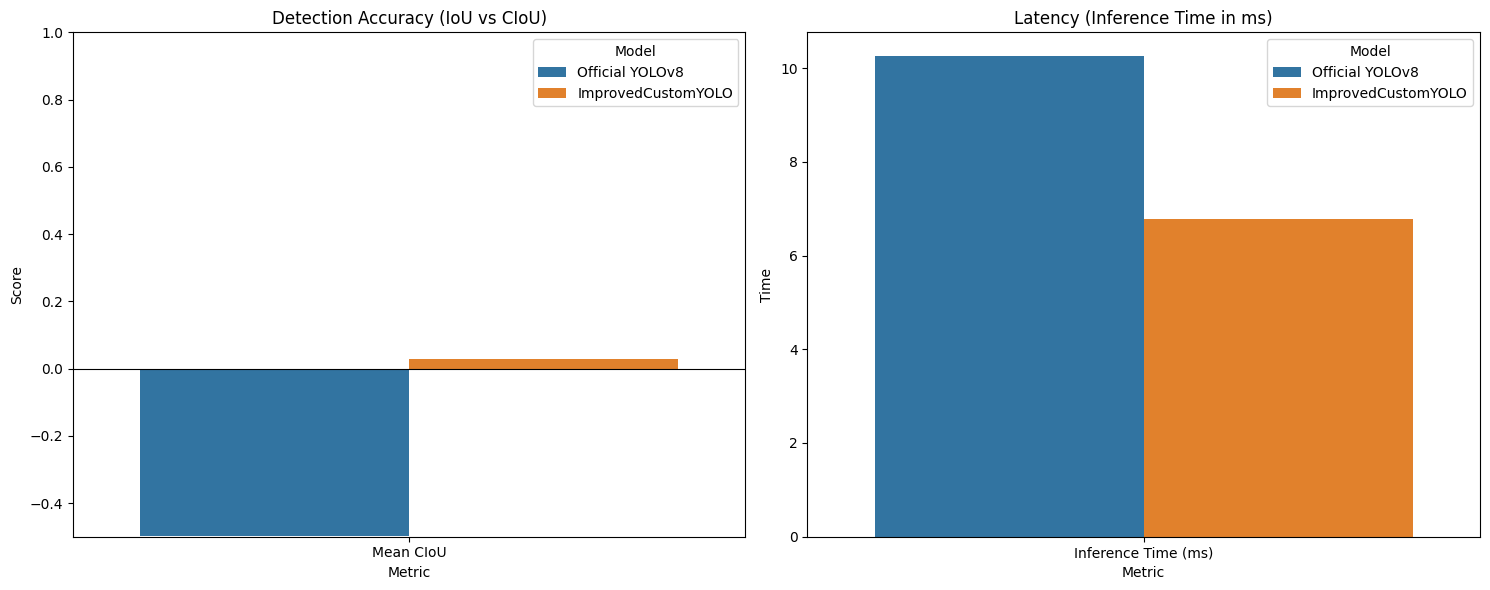

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def visualize_comparison(csv_path='runs/comparison/performance_comparison.csv'):
    if not os.path.exists(csv_path):
        print(f"Comparison file not found at {csv_path}. Please run the 'run-pipeline' cell first.")
        return

    df_comp = pd.read_csv(csv_path)
    df_comp['Official YOLOv8'] = pd.to_numeric(df_comp['Official YOLOv8'])
    df_comp['ImprovedCustomYOLO'] = pd.to_numeric(df_comp['ImprovedCustomYOLO'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Accuracy Metrics (IoU & CIoU)
    acc_metrics = ['Mean IoU', 'Mean CIoU']
    acc_data = df_comp[df_comp['Metric'].isin(acc_metrics)]
    sns.barplot(data=pd.melt(acc_data, id_vars=['Metric'], var_name='Model', value_name='Score'),
                x='Metric', y='Score', hue='Model', ax=axes[0])
    axes[0].set_title('Detection Accuracy (IoU vs CIoU)')
    axes[0].set_ylim(-0.5, 1.0)
    axes[0].axhline(0, color='black', linewidth=0.8)

    # Plot 2: Inference Time
    latency_data = df_comp[df_comp['Metric'] == 'Inference Time (ms)']
    sns.barplot(data=pd.melt(latency_data, id_vars=['Metric'], var_name='Model', value_name='Time'),
                x='Metric', y='Time', hue='Model', ax=axes[1])
    axes[1].set_title('Latency (Inference Time in ms)')

    plt.tight_layout()
    plt.show()

visualize_comparison()

In [54]:
import numpy as np

def debug_ciou_math(box1, box2):
    """Prints the components of the CIoU calculation for debugging."""
    iou = box_iou(box1, box2)
    cx1, cy1 = (box1[0] + box1[2]) / 2.0, (box1[1] + box1[3]) / 2.0
    cx2, cy2 = (box2[0] + box2[2]) / 2.0, (box2[1] + box2[3]) / 2.0
    rho2 = (cx1 - cx2) ** 2 + (cy1 - cy2) ** 2
    enc_x1, enc_y1 = min(box1[0], box2[0]), min(box1[1], box2[1])
    enc_x2, enc_y2 = max(box1[2], box2[2]), max(box1[3], box2[3])
    c2 = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + 1e-7

    dist_penalty = rho2 / c2

    w1, h1 = max(box1[2] - box1[0], 1e-7), max(box1[3] - box1[1], 1e-7)
    w2, h2 = max(box2[2] - box2[0], 1e-7), max(box2[3] - box2[1], 1e-7)
    v = (4.0 / np.pi**2) * (np.arctan(w2 / h2) - np.arctan(w1 / h1)) ** 2
    alpha = v / (1.0 - iou + v + 1e-7)
    aspect_penalty = alpha * v

    ciou = iou - dist_penalty - aspect_penalty

    print(f"IoU: {iou:.4f}")
    print(f"Distance Penalty: -{dist_penalty:.4f}")
    print(f"Aspect Penalty: -{aspect_penalty:.4f}")
    print(f"Final CIoU: {ciou:.4f}")
    return ciou

# Example test using current variables if they exist
if 'official_model' in globals() and 'val_images' in globals():
    img_path = str(val_images[0])
    gt = load_gt_boxes(os.path.join(TARGET_DATASET_DIR, 'val', 'labels', Path(img_path).stem + '.txt'), 640)
    if gt:
        res = official_model.predict(img_path, imgsz=640, verbose=False)[0]
        if res.boxes is not None and len(res.boxes.xyxy) > 0:
            pred = res.boxes.xyxy[0].cpu().tolist()
            print(f"Debugging CIoU for {Path(img_path).name}:")
            debug_ciou_math(pred, gt[0])

Debugging CIoU for Cars1.png:
IoU: 0.0000
Distance Penalty: -0.4088
Aspect Penalty: -0.0001
Final CIoU: -0.4089


## Final Validation Inference Samples

Run final inference on 2-3 validation images for presentation-ready visuals.


Loading weights from: runs/detect/runs/official_yolo/car_plate_model-4/weights/best.pt


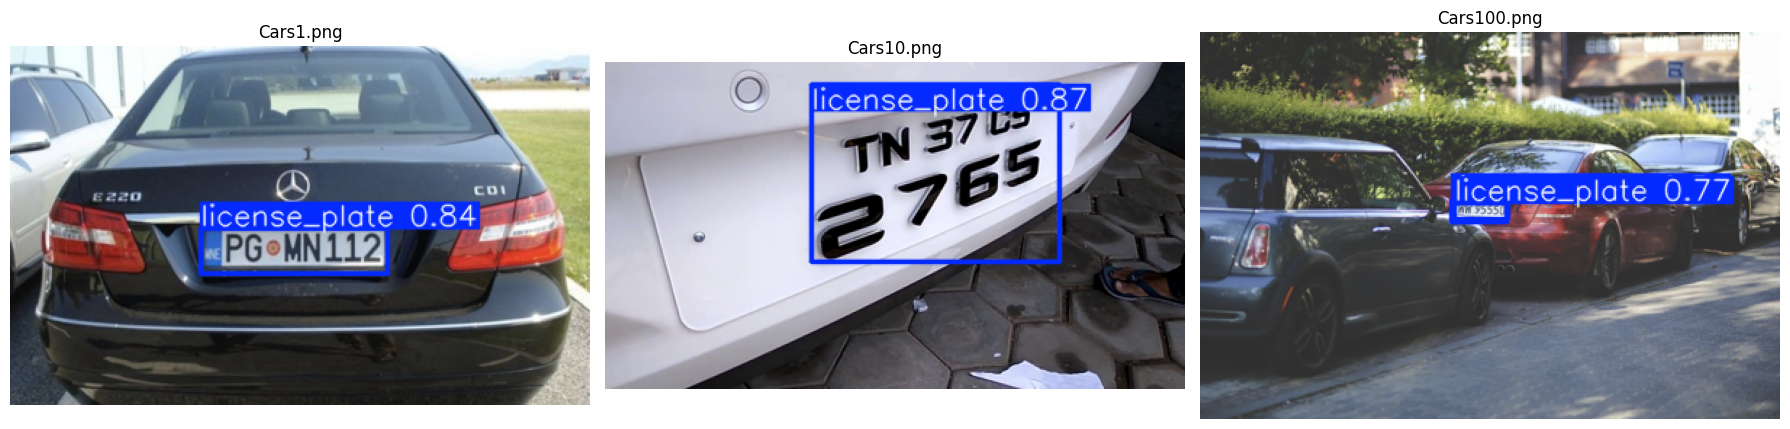

In [52]:
import glob

val_image_dir = Path(TARGET_DATASET_DIR) / "val" / "images"

# Dynamically find the best weights in case the run name has a suffix (like -4)
weight_search = glob.glob("runs/detect/runs/official_yolo/car_plate_model*/weights/best.pt")
if not weight_search:
    weight_search = glob.glob("runs/official_yolo/car_plate_model*/weights/best.pt")

if not weight_search:
    print("Could not find official training weights. Please ensure the 'run-pipeline' cell finished training successfully.")
elif not val_image_dir.exists():
    print(f"Validation directory not found: {val_image_dir}")
else:
    official_best_path = weight_search[-1] # Use the most recent if multiple exist
    val_images = sorted([p for p in val_image_dir.iterdir() if p.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS])[:3]

    if not val_images:
        print(f"No validation images found in {val_image_dir}")
    else:
        print(f"Loading weights from: {official_best_path}")
        official_model = YOLO(official_best_path)

        fig, axes = plt.subplots(1, len(val_images), figsize=(6 * len(val_images), 6))
        if len(val_images) == 1:
            axes = [axes]

        for ax, image_path in zip(axes, val_images):
            result = official_model.predict(source=str(image_path), imgsz=640, verbose=False)[0]
            rendered = result.plot()
            ax.imshow(rendered[:, :, ::-1])
            ax.set_title(image_path.name)
            ax.axis("off")

        plt.tight_layout()
        plt.show()

## AI Disclosure

AI tools were used for architectural brainstorming and debugging support.
The experimental design, training decisions, and performance analysis are original work by the project author.
